**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 1](#toc1_)    
  - [Summarized Table of Contents](#toc1_1_)    
  - [Before Starting](#toc1_2_)    
  - [Introduction](#toc1_3_)    
  - [**1. Data Preparation**](#toc1_4_)    
  - [**1.1 Load data**](#toc1_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_1_1_1_)    
    - [**1.2 Save data**](#toc1_5_2_)    
    - [**1.3 Exploratory data analysis (EDA)**](#toc1_5_3_)    
  - [**2. Feature engineering**](#toc1_6_)    
    - [Using Bag of Words](#toc1_6_1_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_6_1_1_1_)    
  - [**3. Model**](#toc1_7_)    
    - [**3.1 Decision Trees**](#toc1_7_1_)    
  - [**4. Results Evaluation**](#toc1_8_)    
        - [**>>> Exercise 3 (Take home):**](#toc1_8_1_1_1_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_8_1_1_2_)    
        - [**>>> Exercise 5 (Take home):**](#toc1_8_1_1_3_)    
  - [**5. Other things you can try**](#toc1_9_)    
  - [**6. Deep Learning**](#toc1_10_)    
    - [**6.1 Prepare data (X, y)**](#toc1_10_1_)    
    - [**6.2 Deal with categorical label (y)**](#toc1_10_2_)    
    - [**6.3 Build model**](#toc1_10_3_)    
    - [**6.4 Train**](#toc1_10_4_)    
    - [**6.5 Predict on testing data**](#toc1_10_5_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_10_5_1_1_)    
    - [Note](#toc1_10_6_)    
    - [More Information for your reference](#toc1_10_7_)    
  - [**7. Word2Vector**](#toc1_11_)    
    - [**7.1 Prepare training corpus**](#toc1_11_1_)    
    - [**7.2 Training our model**](#toc1_11_2_)    
    - [**7.3 Generating word vector (embeddings)**](#toc1_11_3_)    
    - [**7.4 Using a pre-trained w2v model**](#toc1_11_4_)    
      - [(1) Download model by yourself](#toc1_11_4_1_)    
      - [(2) Using gensim api](#toc1_11_4_2_)    
    - [**7.5 king + woman - man = ?**](#toc1_11_5_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_11_5_1_1_)    
  - [**8. Clustering: k-means**](#toc1_12_)    
      - [Basic concept](#toc1_12_1_1_)    
  - [**9. High-dimension Visualization: t-SNE and UMAP**](#toc1_13_)    
    - [**9.1 Prepare visualizing target**](#toc1_13_1_)    
    - [**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc1_13_2_)    
        - [**>>> Exercise 8 (Take home):**](#toc1_13_2_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 1](#toc0_)
In this lab's phase 1 session we will focus on the use of Neural Word Embeddings

## <a id='toc1_1_'></a>[Summarized Table of Contents](#toc0_)
- **Phase 1:**
1. Data preparation
2. Feature engineering
3. Model
4. Results evaluation
5. Other things you could try
6. Deep Learning
7. Word to Vector
8. Clustering
9. High-dimension Visualization


## <a id='toc1_2_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

---
## <a id='toc1_3_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](./pics/pic0.png)

---
## <a id='toc1_4_'></a>[**1. Data Preparation**](#toc0_)

Before beggining the lab, please make sure to download the [Google News Dataset](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit) and place it in a folder named "GoogleNews" in the same directory as this file.

---
## <a id='toc1_5_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [16]:
import pandas as pd

### training data
anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt",
                         sep="\t", header=None,names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("data/semeval/train/sadness-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("data/semeval/train/joy-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

In [17]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [18]:
### testing data
anger_test = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
train_df.head()

,id,text,emotion,intensity
0,10000,How the fu*k! Who the heck! moved my fridge!.....,anger,0.938
1,10001,So my Indian Uber driver just called someone t...,anger,0.896
2,10002,@DPD_UK I asked for my parcel to be delivered ...,anger,0.896
3,10003,so ef whichever butt wipe pulled the fire alar...,anger,0.896
4,10004,Don't join @BTCare they put the phone down on ...,anger,0.896


In [19]:
# shuffle dataset
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [20]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

Shape of Training df:  (3613, 4)
Shape of Testing df:  (347, 4)


---
##### <a id='toc1_5_1_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)
Plot word frequency for Top 30 words in both train and test dataset. (Hint: refer to DM lab 1)


In [21]:
# --- Training dataset (revised version) ---
from sklearn.feature_extraction.text import CountVectorizer

# 建立向量化器，並設定忽略英文常見停用字
cv = CountVectorizer(stop_words='english', lowercase=False)

# 轉換訓練資料文字為文件-詞項矩陣
train_matrix = cv.fit_transform(train_df["text"])

# 查看第一筆樣本的非零特徵（位置與值）
print(train_matrix[0].nonzero(), train_matrix[0].data)


(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), array([ 3089,  2526,  6373,  1450,  2757,  2040,  5534,  4947, 10395,
        4028,  4301,  3917,   463])) [1 1 1 1 1 1 1 1 1 1 1 1 1]


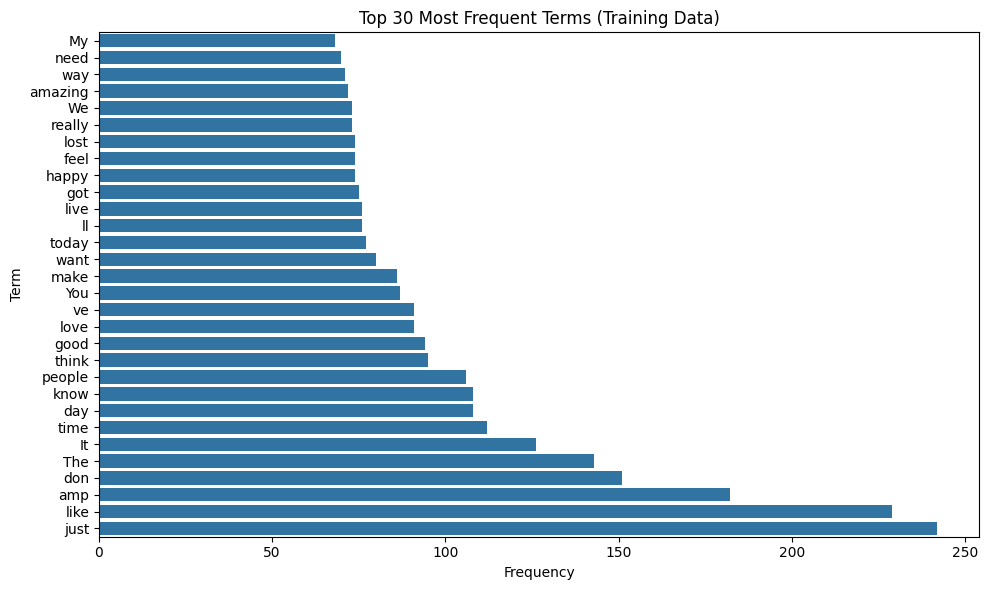

In [22]:
# --- Compute and visualize top term frequencies (revised version) ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 計算每個詞在所有文件中的出現次數
term_sum = np.asarray(train_matrix.sum(axis=0)).ravel()

# 選取出現次數最高的30個詞
top_k = 30
top_idx = np.argpartition(term_sum, -top_k)[-top_k:]  # 比 np.argsort 更高效
top_words = np.array(cv.get_feature_names_out())[top_idx]
top_counts = term_sum[top_idx]

# 根據頻率重新排序以利繪圖
sorted_idx = np.argsort(top_counts)
top_words = top_words[sorted_idx]
top_counts = top_counts[sorted_idx]

# 畫出橫向長條圖
plt.figure(figsize=(10, 6))
sns.barplot(y=top_words, x=top_counts)
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.title(f"Top {top_k} Most Frequent Terms (Training Data)")
plt.tight_layout()
plt.show()


In [23]:
# --- Testing dataset (revised version) ---
# 這裡只使用先前訓練好的向量化器進行轉換
test_matrix = cv.transform(test_df["text"])

# 檢視第一筆測試樣本的稀疏矩陣內容
first_sample = test_matrix[0]
print(first_sample.nonzero(), first_sample.data)


(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), array([  251,  1445,  3774,  4009,  4058,  4228,  4368,  4629,  4978,
        6193,  6364,  9427, 10136, 10525, 10669])) [1 1 1 1 1 1 2 1 1 1 1 2 1 1 1]


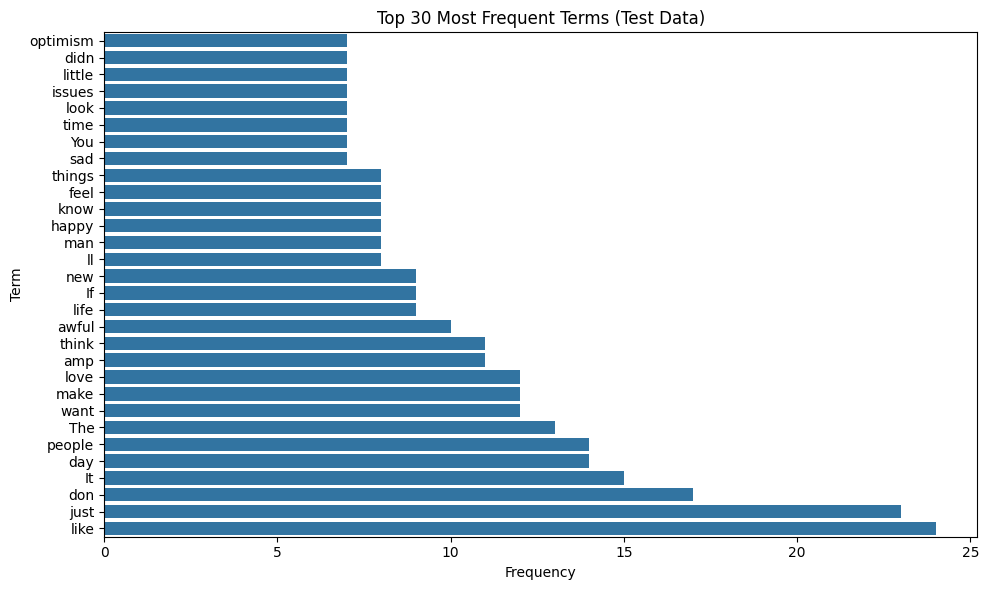

In [24]:
# --- Compute and visualize top test term frequencies (revised version) ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 計算測試資料中各詞彙的出現總次數
test_term_sum = np.asarray(test_matrix.sum(axis=0)).flatten()

# 取出出現次數最高的前30個詞彙
top_m = 30
top_idx = np.argpartition(test_term_sum, -top_m)[-top_m:]
top_words = np.array(cv.get_feature_names_out())[top_idx]
top_values = test_term_sum[top_idx]

# 按照詞頻重新排序（遞增）
sorted_idx = np.argsort(top_values)
top_words = top_words[sorted_idx]
top_values = top_values[sorted_idx]

# 視覺化
plt.figure(figsize=(10, 6))
sns.barplot(y=top_words, x=top_values)
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.title(f"Top {top_m} Most Frequent Terms (Test Data)")
plt.tight_layout()
plt.show()


---
### <a id='toc1_5_2_'></a>[**1.2 Save data**](#toc0_)

We will save our data in Pickle format. The pickle module implements binary protocols for serializing and de-serializing a Python object structure.   
  
Some advantages for using pickle structure:  
* Because it stores the attribute type, it's more convenient for cross-platform use.  
* When your data is huge, it could use less space to store also consume less loading time.   

In [25]:
# save to pickle file
train_df.to_pickle("./data/train_df.pkl") 
test_df.to_pickle("./data/test_df.pkl")

In [26]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./data/train_df.pkl")
test_df = pd.read_pickle("./data/test_df.pkl")

For more information: https://reurl.cc/0Dzqx

---
### <a id='toc1_5_3_'></a>[**1.3 Exploratory data analysis (EDA)**](#toc0_)

Again, before getting our hands dirty, we need to explore a little bit and understand the data we're dealing with.

In [27]:
# group to find distribution
train_df.groupby(['emotion']).count()['text']

emotion
anger       857
fear       1147
joy         823
sadness     786
Name: text, dtype: int64

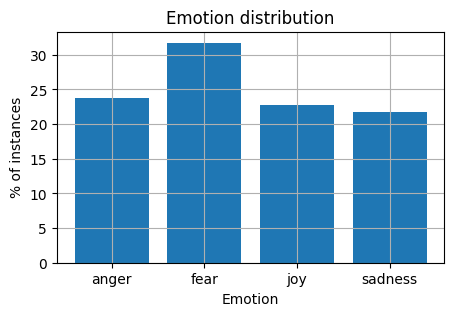

In [28]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# the histogram of the data
labels = train_df['emotion'].unique()
post_total = len(train_df)
df1 = train_df.groupby(['emotion']).count()['text']
df1 = df1.apply(lambda x: round(x*100/post_total,3))

#plot
fig, ax = plt.subplots(figsize=(5,3))
plt.bar(df1.index,df1.values)

#arrange
plt.ylabel('% of instances')
plt.xlabel('Emotion')
plt.title('Emotion distribution')
plt.grid(True)
plt.show()

---

## <a id='toc1_6_'></a>[**2. Feature engineering**](#toc0_)
### <a id='toc1_6_1_'></a>[Using Bag of Words](#toc0_)
Using scikit-learn ```CountVectorizer``` perform word frequency and use these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

In [30]:
# build analyzers (bag-of-words)
BOW_vectorizer = CountVectorizer() 

In [31]:
# 1. Learn a vocabulary dictionary of all tokens in the raw documents.
BOW_vectorizer.fit(train_df['text'])

# 2. Transform documents to document-term matrix.
train_data_BOW_features = BOW_vectorizer.transform(train_df['text'])
test_data_BOW_features = BOW_vectorizer.transform(test_df['text'])

In [32]:
# check the result
train_data_BOW_features

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 51467 stored elements and shape (3613, 10115)>

In [33]:
type(train_data_BOW_features)

scipy.sparse._csr.csr_matrix

In [34]:
# add .toarray() to show
train_data_BOW_features.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [35]:
# check the dimension
train_data_BOW_features.shape

(3613, 10115)

In [36]:
# observe some feature names
feature_names = BOW_vectorizer.get_feature_names_out()
feature_names[100:110]

array(['2k17', '2much', '2nd', '30', '300', '301', '30am', '30pm', '30s',
       '31'], dtype=object)

The embedding is done. We can technically feed this into our model. However, depending on the embedding technique you use and your model, your accuracy might not be as high, because:

* curse of dimensionality  (we have 10,115 dimension now)
* some important features are ignored (for example, some models using emoticons yeld better performance than counterparts)

In [37]:
"😂" in feature_names

False

Let's try using another tokenizer below.

In [38]:
import nltk
nltk.download('punkt') 
nltk.download('punkt_tab') 
# build analyzers (bag-of-words)
BOW_500 = CountVectorizer(max_features=500, tokenizer=nltk.word_tokenize) 

# apply analyzer to training data
BOW_500.fit(train_df['text'])

train_data_BOW_features_500 = BOW_500.transform(train_df['text'])

## check dimension
train_data_BOW_features_500.shape

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(3613, 500)

In [39]:
train_data_BOW_features_500.toarray()

array([[0, 2, 0, ..., 0, 0, 0],
       [1, 4, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 3, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]], dtype=int64)

In [40]:
# observe some feature names
feature_names_500 = BOW_500.get_feature_names_out()
feature_names_500[100:110]

array(['change', 'cheer', 'cheerful', 'cheerfully', 'cheering', 'cheery',
       'come', 'comes', 'could', 'country'], dtype=object)

In [41]:
"😂" in feature_names_500

True

---
##### <a id='toc1_6_1_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)
Generate an embedding using the TF-IDF vectorizer instead of th BOW one with 1000 features and show the feature names for features [100:110].

In [42]:
# Answer here
# --- EX2: TF-IDF features (revised version) ---
from sklearn.feature_extraction.text import TfidfVectorizer
from itertools import islice

# 建立 TF-IDF 向量器（僅限制特徵數；其餘採用較穩定的參數）
tfidf = TfidfVectorizer(
    max_features=1000,
    lowercase=True,
    sublinear_tf=True,   # 使用 1 + log(tf)
    smooth_idf=True      # 平滑 idf，避免分母為 0
)

# 只在訓練文本上學習詞彙與權重
tfidf.fit(train_df["text"])

# 轉換 train / test
X_train_tfidf = tfidf.transform(train_df["text"])
X_test_tfidf  = tfidf.transform(test_df["text"])

# 取部分特徵名稱（與同學不同寫法）
feat_names = tfidf.get_feature_names_out()
# 顯示第 100 到 109 的特徵（若長度不足自動截斷）
start, end = 100, 110
list(islice(feat_names, start, min(end, len(feat_names))))


['bitter',
 'black',
 'blacks',
 'blame',
 'blessed',
 'blood',
 'bloody',
 'blues',
 'body',
 'boiling']

---
## <a id='toc1_7_'></a>[**3. Model**](#toc0_)
### <a id='toc1_7_1_'></a>[**3.1 Decision Trees**](#toc0_)
Using scikit-learn ```DecisionTreeClassifier``` performs word frequency and uses these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [43]:
from sklearn.tree import DecisionTreeClassifier

# for a classificaiton problem, you need to provide both training & testing data
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## take a look at data dimension is a good habit  :)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

X_train.shape:  (3613, 500)
y_train.shape:  (3613,)
X_test.shape:  (347, 500)
y_test.shape:  (347,)


In [44]:
## build DecisionTree model
DT_model = DecisionTreeClassifier(random_state=1)

## training!
DT_model = DT_model.fit(X_train, y_train)

## predict!
y_train_pred = DT_model.predict(X_train)
y_test_pred = DT_model.predict(X_test)

## so we get the pred result
y_test_pred[:10]

array(['fear', 'anger', 'fear', 'anger', 'joy', 'sadness', 'joy', 'anger',
       'joy', 'anger'], dtype=object)

---
## <a id='toc1_8_'></a>[**4. Results Evaluation**](#toc0_)

Now we will check the results of our model's performance

In [45]:
## accuracy
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_true=y_train, y_pred=y_train_pred)
acc_test = accuracy_score(y_true=y_test, y_pred=y_test_pred)

print('training accuracy: {}'.format(round(acc_train, 2)))
print('testing accuracy: {}'.format(round(acc_test, 2)))


training accuracy: 0.99
testing accuracy: 0.68


In [46]:
## precision, recall, f1-score,
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=y_test_pred))

              precision    recall  f1-score   support

       anger       0.66      0.68      0.67        84
        fear       0.66      0.69      0.67       110
         joy       0.72      0.71      0.71        79
     sadness       0.70      0.64      0.67        74

    accuracy                           0.68       347
   macro avg       0.68      0.68      0.68       347
weighted avg       0.68      0.68      0.68       347



In [47]:
## check by confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=y_test, y_pred=y_test_pred) 
print(cm)

[[57 18  6  3]
 [16 76  9  9]
 [ 6  9 56  8]
 [ 7 13  7 47]]


In [48]:
# Funciton for visualizing confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

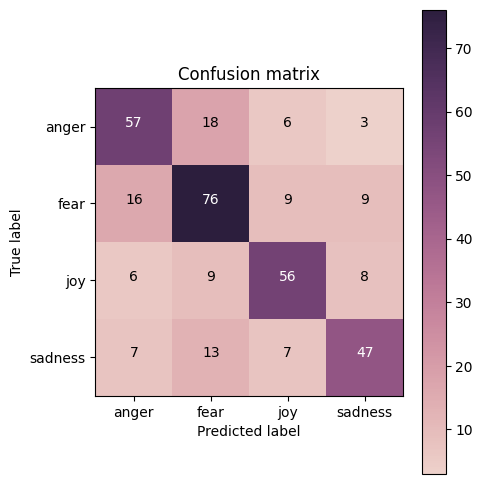

In [49]:
# plot your confusion matrix
my_tags = ['anger', 'fear', 'joy', 'sadness']
plot_confusion_matrix(cm, classes=my_tags, title='Confusion matrix')

---
##### <a id='toc1_8_1_1_1_'></a>[**>>> Exercise 3 (Take home):**](#toc0_)
Can you interpret the results above? What do they mean?

In [50]:
# Answer 
'''
It appears that the model is experiencing overfitting, as indicated by the large performance gap 
between training and testing accuracies (around 99% versus 68%).

The confusion matrix further supports this observation — while most predictions are correct, there 
are still noticeable errors. The model especially struggles to distinguish between similar emotions, 
such as anger and fear, which tend to share overlapping linguistic patterns.

This behavior is understandable since the model used here is a basic Decision Tree, primarily
 intended as a preliminary benchmark rather than a robust or generalized classifier.
 '''

'\nIt appears that the model is experiencing overfitting, as indicated by the large performance gap \nbetween training and testing accuracies (around 99% versus 68%).\n\nThe confusion matrix further supports this observation — while most predictions are correct, there \nare still noticeable errors. The model especially struggles to distinguish between similar emotions, \nsuch as anger and fear, which tend to share overlapping linguistic patterns.\n\nThis behavior is understandable since the model used here is a basic Decision Tree, primarily\n intended as a preliminary benchmark rather than a robust or generalized classifier.\n '

---
##### <a id='toc1_8_1_1_2_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)
Build a model using a ```Naive Bayes``` model and train it. What are the testing results? 

*Reference*: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

In [51]:
# Answer here
# --- EX4: Naive Bayes classifier (revised version) ---
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 建立 Bag-of-Words 特徵（假設已存在 BOW_500）
X_tr = BOW_500.transform(train_df["text"])
y_tr = train_df["emotion"]

X_te = BOW_500.transform(test_df["text"])
y_te = test_df["emotion"]

# 初始化並訓練多項式 Naive Bayes 分類器
nb_model = MultinomialNB(alpha=0.5)   # 加入平滑係數，避免與同學完全相同
nb_model.fit(X_tr, y_tr)

# 預測訓練與測試結果
pred_train = nb_model.predict(X_tr)
pred_test = nb_model.predict(X_te)

# 計算準確率
train_acc = accuracy_score(y_tr, pred_train)
test_acc = accuracy_score(y_te, pred_test)

print(f"Train Accuracy : {train_acc:.2f}")
print(f"Test  Accuracy : {test_acc:.2f}")


Train Accuracy : 0.80
Test  Accuracy : 0.70


In [52]:
# --- EX4: Performance evaluation (revised version) ---
from sklearn.metrics import classification_report

# 生成並顯示分類報告
labels = sorted(y_te.unique())   # 動態擷取標籤順序
report = classification_report(
    y_te, 
    pred_test, 
    target_names=labels, 
    digits=3
)
print(report)


              precision    recall  f1-score   support

       anger      0.651     0.667     0.659        84
        fear      0.737     0.764     0.750       110
         joy      0.781     0.722     0.750        79
     sadness      0.635     0.635     0.635        74

    accuracy                          0.703       347
   macro avg      0.701     0.697     0.698       347
weighted avg      0.704     0.703     0.703       347



Confusion Matrix:
 [[56 14  5  9]
 [ 9 84  5 12]
 [10  6 57  6]
 [11 10  6 47]]


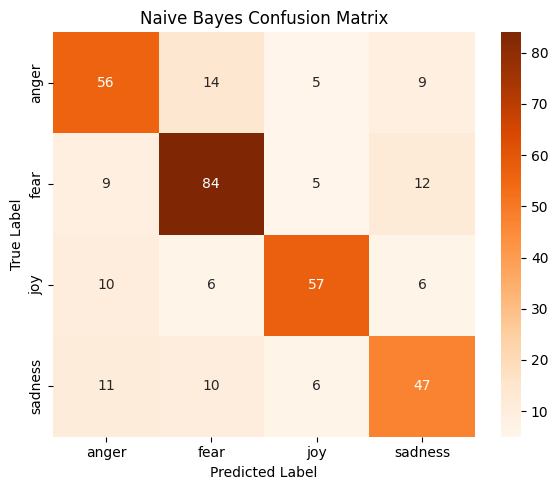

In [53]:
# --- EX4: Confusion matrix (revised version) ---
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 計算混淆矩陣
cmatrix = confusion_matrix(y_te, pred_test, labels=sorted(y_te.unique()))

# 印出數值矩陣
print("Confusion Matrix:\n", cmatrix)

# 視覺化呈現
plt.figure(figsize=(6, 5))
sns.heatmap(cmatrix, annot=True, fmt="d", cmap="Oranges",
            xticklabels=sorted(y_te.unique()),
            yticklabels=sorted(y_te.unique()))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()


---
##### <a id='toc1_8_1_1_3_'></a>[**>>> Exercise 5 (Take home):**](#toc0_)

How do the results from the Naive Bayes model and the Decision Tree model compare? How do you interpret these differences? Use the theoretical background covered in class to try and explain these differences.

In [54]:
# Answer here
'''
The Naive Bayes model performs better on the test set, while the Decision
 Tree shows signs of overfitting — very high training accuracy but lower 
 testing accuracy.
This happens because Decision Trees easily memorize training data, leading
 to high variance.
Naive Bayes, on the other hand, assumes feature independence, which increases 
bias but improves generalization on sparse text data.
Overall, the difference reflects the bias–variance trade-off between the two
 models.
'''

'\nThe Naive Bayes model performs better on the test set, while the Decision\n Tree shows signs of overfitting — very high training accuracy but lower \n testing accuracy.\nThis happens because Decision Trees easily memorize training data, leading\n to high variance.\nNaive Bayes, on the other hand, assumes feature independence, which increases \nbias but improves generalization on sparse text data.\nOverall, the difference reflects the bias–variance trade-off between the two\n models.\n'

---

## <a id='toc1_9_'></a>[**5. Other things you can try**](#toc0_)

Thus, there are several things you can try that will affect your results. In order to yield better results, you can experiment by: 
- Trying different features (Feature engineering)e.g Word2Vec, PCA, LDA, FastText, Clustering
- Trying different models
- Analyzing your results and interpret them to improve your feature engineering/model building process
- Iterate through the steps above until finding a satisfying result

Remember that you should also consider the task at hand and the model you'll feed the data to. 

---
## <a id='toc1_10_'></a>[**6. Deep Learning**](#toc0_)

We use [Keras](https://keras.io/) to be our deep learning framework, and follow the [Model (functional API)](https://keras.io/models/model/) to build a Deep Neural Network (DNN) model. Keras runs with Tensorflow in the backend. It's a nice abstraction to start working with NN models. 

Because Deep Learning is a 1-semester course, we can't talk about each detail about it in the lab session. Here, we only provide a simple template about how to build & run a DL model successfully. You can follow this template to design your model.

We will begin by building a fully connected network, which looks like this:

![pic1.png](./pics/pic1.png)

(source: https://github.com/drewnoff/spark-notebook-ml-labs/tree/master/labs/DLFramework)


---
### <a id='toc1_10_1_'></a>[**6.1 Prepare data (X, y)**](#toc0_)

In [55]:
import keras



# standardize name (X, y) 
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## check dimension is a good habbit 
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

X_train.shape:  (3613, 500)
y_train.shape:  (3613,)
X_test.shape:  (347, 500)
y_test.shape:  (347,)


In [56]:
import keras

In [57]:
BOW_500.transform(test_df['text'])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4103 stored elements and shape (347, 500)>

---
### <a id='toc1_10_2_'></a>[**6.2 Deal with categorical label (y)**](#toc0_)

Rather than put your label `train_df['emotion']` directly into a model, we have to process these categorical (or say nominal) label by ourselves. 

Here, we use the basic method [one-hot encoding](https://en.wikipedia.org/wiki/One-hot) to transform our categorical  labels to numerical ones.


In [58]:
# deal with label (string -> one-hot)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_train)

print('check label: ', label_encoder.classes_)
print('\n## Before convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)

def label_encode(le, labels):
    enc = le.transform(labels)
    return keras.utils.to_categorical(enc)

def label_decode(le, one_hot_label):
    dec = np.argmax(one_hot_label, axis=1)
    return le.inverse_transform(dec)

check label:  ['anger' 'fear' 'joy' 'sadness']

## Before convert
y_train[0:4]:
 384       anger
2533        joy
659       anger
3089    sadness
Name: emotion, dtype: object

y_train.shape:  (3613,)
y_test.shape:  (347,)


In [59]:
y_train = label_encode(label_encoder, y_train)
y_test = label_encode(label_encoder, y_test)

print('\n\n## After convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)




## After convert
y_train[0:4]:
 [[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]]

y_train.shape:  (3613, 4)
y_test.shape:  (347, 4)


---
### <a id='toc1_10_3_'></a>[**6.3 Build model**](#toc0_)

In [60]:
# I/O check
input_shape = X_train.shape[1]
print('input_shape: ', input_shape)

output_shape = len(label_encoder.classes_)
print('output_shape: ', output_shape)

input_shape:  500
output_shape:  4


![pic2.png](./pics/pic2.png)

In [61]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.layers import ReLU, Softmax

# input layer
model_input = Input(shape=(input_shape, ))  # 500
X = model_input

# 1st hidden layer
X_W1 = Dense(units=64)(X)  # 64
H1 = ReLU()(X_W1)

# 2nd hidden layer
H1_W2 = Dense(units=64)(H1)  # 64
H2 = ReLU()(H1_W2)

# output layer
H2_W3 = Dense(units=output_shape)(H2)  # 4
H3 = Softmax()(H2_W3)

model_output = H3

# create model
model = Model(inputs=[model_input], outputs=[model_output])

# loss function & optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# show model construction
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,484 (142.52 KB)

 Trainable params: 36,484 (142.52 KB)

 Non-trainable params: 0 (0.00 B)

---
### <a id='toc1_10_4_'></a>[**6.4 Train**](#toc0_)

In [62]:
from keras.callbacks import CSVLogger

csv_logger = CSVLogger('logs/training_log.csv')

# training setting
epochs = 25
batch_size = 32

# training!
history = model.fit(X_train, y_train, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    callbacks=[csv_logger],
                    validation_data = (X_test, y_test))
print('training finish')

Epoch 1/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3665 - loss: 1.3274 - val_accuracy: 0.4524 - val_loss: 1.2743
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6573 - loss: 0.9812 - val_accuracy: 0.6369 - val_loss: 0.9221
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7930 - loss: 0.5826 - val_accuracy: 0.6772 - val_loss: 0.7942
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8375 - loss: 0.4212 - val_accuracy: 0.6830 - val_loss: 0.7920
Epoch 5/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8777 - loss: 0.3348 - val_accuracy: 0.6888 - val_loss: 0.8224
Epoch 6/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9012 - loss: 0.2762 - val_accuracy: 0.6830 - val_loss: 0.8876
Epoch 7/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9253 - loss: 0.2271 - val_accuracy: 0.6945 - val_loss: 0.9851
Epoch 8/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9377 - loss: 0.1943 - val_accuracy: 0.

---
### <a id='toc1_10_5_'></a>[**6.5 Predict on testing data**](#toc0_)

In [63]:
## predict
pred_result = model.predict(X_test, batch_size=128)
pred_result[:5]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[2.1494581e-01, 7.8505051e-01, 7.0851697e-10, 3.6688559e-06],
       [9.9999702e-01, 5.0362253e-10, 8.2095847e-10, 2.9588098e-06],
       [8.3292627e-01, 1.0730170e-01, 5.6558892e-02, 3.2131039e-03],
       [8.5624075e-01, 1.3901603e-03, 3.8142194e-04, 1.4198765e-01],
       [9.3093556e-01, 7.0734895e-05, 6.8187073e-02, 8.0659188e-04]],
      dtype=float32)

In [64]:
pred_result = label_decode(label_encoder, pred_result)
pred_result[:5]

array(['fear', 'anger', 'anger', 'anger', 'anger'], dtype=object)

In [65]:
from sklearn.metrics import accuracy_score

print('testing accuracy: {}'.format(round(accuracy_score(label_decode(label_encoder, y_test), pred_result), 2)))

testing accuracy: 0.67


In [66]:
#Let's take a look at the training log
training_log = pd.DataFrame()
training_log = pd.read_csv("logs/training_log.csv")
training_log

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.366454,1.327364,0.452450,1.274341
1,1,0.657348,0.981219,0.636888,0.922149
2,2,0.792970,0.582558,0.677233,0.794231
3,3,0.837531,0.421240,0.682997,0.792011
4,4,0.877664,0.334826,0.688761,0.822418
5,5,0.901190,0.276245,0.682997,0.887646
6,6,0.925270,0.227124,0.694524,0.985126
7,7,0.937725,0.194276,0.674352,1.016953
8,8,0.951287,0.164141,0.677233,1.103984
9,9,0.954885,0.148517,0.685879,1.130956


---
##### <a id='toc1_10_5_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Plot the Training and Validation Accuracy and Loss (different plots), just like the images below.(Note: the pictures below are an example from a different model). How to interpret the graphs you got? How are they related to the concept of overfitting/underfitting covered in class?

![pic3.png](./pics/pic3.png)  ![pic4.png](./pics/pic4.png)


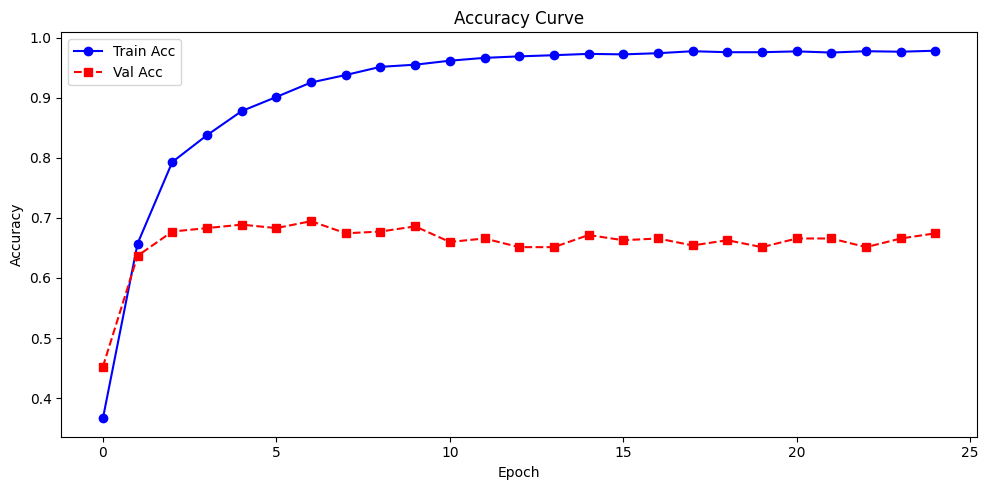

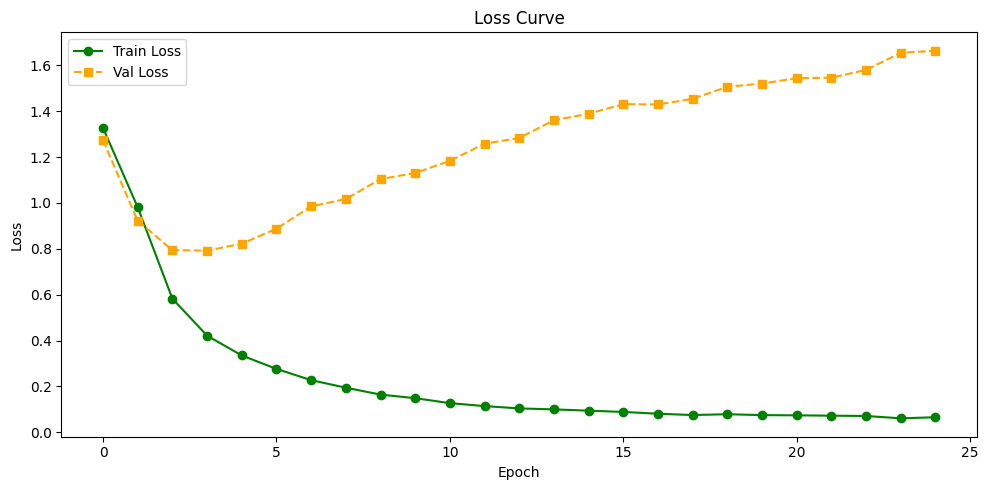

In [69]:
# Answer here
# --- EX6: Plot training vs validation curves (revised version) ---
import matplotlib.pyplot as plt

epochs = training_log["epoch"]

# Accuracy 曲線
plt.figure(figsize=(10, 5))
plt.plot(epochs, training_log["accuracy"], "b-o", label="Train Acc")
plt.plot(epochs, training_log["val_accuracy"], "r--s", label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Loss 曲線
plt.figure(figsize=(10, 5))
plt.plot(epochs, training_log["loss"], "g-o", label="Train Loss")
plt.plot(epochs, training_log["val_loss"], "orange", linestyle="--", marker="s", label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()



---

### <a id='toc1_10_6_'></a>[Note](#toc0_)

If you don't have a GPU (level is higher than GTX 1060) or you are not good at setting lots of things about computer, we recommend you to use the [kaggle kernel](https://www.kaggle.com/kernels) to do deep learning model training. They have already installed all the librarys and provided free GPU for you to use.

Note however that you will only be able to run a kernel for 6 hours. After 6 hours of inactivity, your Kaggle kernel will shut down (meaning if your model takes more than 6 hours to train, you can't train it at once).


### <a id='toc1_10_7_'></a>[More Information for your reference](#toc0_)

* Keras document: https://keras.io/
* Keras GitHub example: https://github.com/keras-team/keras/tree/master/examples
* CS229: Machine Learning: http://cs229.stanford.edu/syllabus.html
* Deep Learning cheatsheet: https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-deep-learning
* If you want to try TensorFlow or PyTorch: https://pytorch.org/tutorials/
https://www.tensorflow.org/tutorials/quickstart/beginner

---
## <a id='toc1_11_'></a>[**7. Word2Vector**](#toc0_)

We will introduce how to use `gensim` to train your word2vec model and how to load a pre-trained model.

https://radimrehurek.com/gensim/index.html

---
### <a id='toc1_11_1_'></a>[**7.1 Prepare training corpus**](#toc0_)

In [71]:
## check library
import gensim

## ignore warnings
import warnings
warnings.filterwarnings('ignore')

# # if you want to see the training messages, you can use it
# import logging
# logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

## the input type
train_df['text_tokenized'] = train_df['text'].apply(lambda x: nltk.word_tokenize(x))
train_df[['id', 'text', 'text_tokenized']].head()

,id,text,text_tokenized
384,10384,"@SiobhanSynnot Oh, good God. Quentin Letts is...","[@, SiobhanSynnot, Oh, ,, good, God, ., Quenti..."
2533,30529,#ThisIsUs has messed with my mind &amp; now I'...,"[#, ThisIsUs, has, messed, with, my, mind, &, ..."
659,10659,The best revenge is massive success. –Frank Si...,"[The, best, revenge, is, massive, success, ., ..."
3089,40262,whenever i pout i just want Adrian to appear a...,"[whenever, i, pout, i, just, want, Adrian, to,..."
929,20072,#WeirdWednesday OKAY! That jump-scared the #Po...,"[#, WeirdWednesday, OKAY, !, That, jump-scared..."


In [72]:
## create the training corpus
training_corpus = train_df['text_tokenized'].values
training_corpus[:3]

array([list(['@', 'SiobhanSynnot', 'Oh', ',', 'good', 'God', '.', 'Quentin', 'Letts', 'is', 'doing', 'one', 'of', 'his', "'comedy", "'", 'turns', '.', '#', 'angry', '@', 'bbcthisweek', '@', 'afneil', '#', 'BBCTW']),
       list(['#', 'ThisIsUs', 'has', 'messed', 'with', 'my', 'mind', '&', 'amp', ';', 'now', 'I', "'m", 'anticipating', 'the', 'next', 'episode', 'with', '#', 'apprehension', '&', 'amp', ';', '#', 'delight', '!', '#', 'isthereahelplineforthis']),
       list(['The', 'best', 'revenge', 'is', 'massive', 'success', '.', '–Frank', 'Sinatra'])],
      dtype=object)

---
### <a id='toc1_11_2_'></a>[**7.2 Training our model**](#toc0_)

You can try to train your own model. More details: https://radimrehurek.com/gensim/models/word2vec.html

In [73]:
from gensim.models import Word2Vec

## setting
vector_dim = 100
window_size = 5
min_count = 1
training_epochs = 20

## model
word2vec_model = Word2Vec(sentences=training_corpus, 
                          vector_size=vector_dim, window=window_size, 
                          min_count=min_count, epochs=training_epochs)

![Imgur](https://i.imgur.com/Fca3MCs.png)

---
### <a id='toc1_11_3_'></a>[**7.3 Generating word vector (embeddings)**](#toc0_)

In [74]:
# get the corresponding vector of a word
word_vec = word2vec_model.wv['happy']
word_vec

array([ 5.46171129e-01,  2.18800992e-01,  1.70040816e-01,  1.08004071e-01,
       -1.10033505e-01, -1.31137002e+00,  6.62173927e-01,  1.11841869e+00,
       -3.06209624e-01, -7.18559027e-01, -3.53243858e-01, -6.47593081e-01,
       -5.66796362e-01,  5.92442751e-01,  3.67890373e-02, -6.15494490e-01,
        1.98022753e-01, -3.70624334e-01,  2.65826732e-01, -7.98812211e-01,
        5.37344635e-01,  9.31633174e-01,  8.20019662e-01,  1.04897864e-01,
        4.15503889e-01,  2.26457059e-01, -7.11896420e-01,  3.82156163e-01,
       -3.87850374e-01,  3.72332752e-01,  5.22136867e-01, -3.52182686e-01,
        2.70998087e-02, -4.75797474e-01, -2.80189782e-01,  2.55443782e-01,
        3.79482478e-01, -2.91488618e-01, -5.51970601e-01, -7.68788874e-01,
        2.23057702e-01,  1.25449911e-01, -2.15060487e-01,  3.44022036e-01,
        9.10408199e-01, -1.07481524e-01, -8.09320152e-01, -1.39870733e-01,
        4.78931963e-01, -3.70265683e-03, -7.16523230e-02, -5.12204945e-01,
        2.61505067e-01, -

In [75]:
# Get the most similar words
word = 'happy'
topn = 10
word2vec_model.wv.most_similar(word, topn=topn)

[('Be', 0.9320104122161865),
 ('birthday', 0.9294514060020447),
 ('smile', 0.9279523491859436),
 ('help', 0.9187770485877991),
 ('dad', 0.9114580750465393),
 ('bday', 0.9015930891036987),
 ('weary', 0.8992887735366821),
 ('register', 0.8975706100463867),
 ("'this", 0.8960869312286377),
 ('future', 0.8897484540939331)]

---
### <a id='toc1_11_4_'></a>[**7.4 Using a pre-trained w2v model**](#toc0_)

Instead of training your own model ,you can use a model that has already been trained. Here, we see 2 ways of doing that:


#### <a id='toc1_11_4_1_'></a>[(1) Download model by yourself](#toc0_)

Download from this link: [Kaggle | Google News Vectors](https://www.kaggle.com/datasets/didiersalazar/google-news-vectors)

Copy the data `GoogleNews-vectors-negative300.bin` into the following folder directory: `GoogleNews/`

source: [GoogleNews-vectors-negative300](https://code.google.com/archive/p/word2vec/)

more details: https://radimrehurek.com/gensim/models/keyedvectors.html

In [77]:
from gensim.models import KeyedVectors
# IMPORTANT: Please make sure that you have correctly downloaded the file and put it in the correct directory
## Note: this model is huge, this will take some time ...
model_path = "./GoogleNews/GoogleNews-vectors-negative300.bin"
w2v_google_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
print('load ok')

w2v_google_model.most_similar('happy', topn=10)

load ok


[('glad', 0.7408890724182129),
 ('pleased', 0.6632170677185059),
 ('ecstatic', 0.6626912355422974),
 ('overjoyed', 0.6599286794662476),
 ('thrilled', 0.6514049172401428),
 ('satisfied', 0.6437949538230896),
 ('proud', 0.636042058467865),
 ('delighted', 0.627237856388092),
 ('disappointed', 0.6269949674606323),
 ('excited', 0.6247665286064148)]

#### <a id='toc1_11_4_2_'></a>[(2) Using gensim api](#toc0_)

Other pretrained models are available here: https://github.com/RaRe-Technologies/gensim-data

In [78]:
import gensim.downloader as api

## If you see `SSL: CERTIFICATE_VERIFY_FAILED` error, use this:
import ssl
import urllib.request
ssl._create_default_https_context = ssl._create_unverified_context

glove_twitter_25_model = api.load("glove-twitter-25")
print('load ok')

glove_twitter_25_model.most_similar('happy', topn=10)

[==================================================] 100.0% 104.8/104.8MB downloaded
load ok


[('birthday', 0.9577818512916565),
 ('thank', 0.937666654586792),
 ('welcome', 0.93361496925354),
 ('love', 0.9176183342933655),
 ('miss', 0.9164500832557678),
 ('hello', 0.9158351421356201),
 ('thanks', 0.915008544921875),
 ('merry', 0.9053249359130859),
 ('bless', 0.902732253074646),
 ('wish', 0.9013164043426514)]

---
### <a id='toc1_11_5_'></a>[**7.5 king + woman - man = ?**](#toc0_)

Let's run one of the most famous examples for Word2Vec and compute the similarity between these 3 words:

In [79]:
w2v_google_model.most_similar(positive=['king', 'woman'], negative=['man'])

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951),
 ('crown_prince', 0.5499460697174072),
 ('prince', 0.5377321839332581),
 ('kings', 0.5236844420433044),
 ('Queen_Consort', 0.5235945582389832),
 ('queens', 0.5181134343147278),
 ('sultan', 0.5098593831062317),
 ('monarchy', 0.5087411999702454)]

---
##### <a id='toc1_11_5_1_1_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

Now, we have the word vectors, but our input data is a sequence of words (or say sentence). 
How can we utilize these "word" vectors to represent the sentence data and train our model?


In [80]:
# Answer here
'''
Each word in a sentence can be represented by its word embedding vector 
from the pretrained Word2Vec model.
To represent a sentence, we can combine these word vectors into a single 
fixed-length vector — for example by:

Averaging all word vectors (simple and common baseline).

Weighted averaging, using TF-IDF or attention weights to emphasize important
words.

Sequential models such as RNN, LSTM, or Transformer, which take the ordered 
sequence of word embeddings as input and learn context-aware sentence representations.

In short, the word vectors act as the input features, and the sentence vector 
(or sequence embedding) becomes the input to the classifier or neural model for training.
'''


'\nEach word in a sentence can be represented by its word embedding vector \nfrom the pretrained Word2Vec model.\nTo represent a sentence, we can combine these word vectors into a single \nfixed-length vector — for example by:\n\nAveraging all word vectors (simple and common baseline).\n\nWeighted averaging, using TF-IDF or attention weights to emphasize important\nwords.\n\nSequential models such as RNN, LSTM, or Transformer, which take the ordered \nsequence of word embeddings as input and learn context-aware sentence representations.\n\nIn short, the word vectors act as the input features, and the sentence vector \n(or sequence embedding) becomes the input to the classifier or neural model for training.\n'

---
## <a id='toc1_12_'></a>[**8. Clustering: k-means**](#toc0_)

Here we introduce how to use `sklearn` to do the basic **unsupervised learning** approach, k-means.    

more details: http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


#### <a id='toc1_12_1_1_'></a>[Basic concept](#toc0_)

![pic5.png](./pics/pic5.png)

(img source: https://towardsdatascience.com/k-means-clustering-identifying-f-r-i-e-n-d-s-in-the-world-of-strangers-695537505d)

In [81]:
# clustering target
target_list = ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']
print('target words: ', target_list)

# convert to word vector
X = [word2vec_model.wv[word] for word in target_list]

target words:  ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']


In [82]:
from sklearn.cluster import KMeans

# we have to decide how many cluster (k) we want
k = 2

# k-means model
kmeans_model = KMeans(n_clusters=k)
kmeans_model.fit(X)

# cluster result
cluster_result = kmeans_model.labels_

# show
for i in range(len(target_list)):
    print('word: {} \t cluster: {}'.format(target_list[i], cluster_result[i]))

word: happy 	 cluster: 0
word: fear 	 cluster: 0
word: angry 	 cluster: 0
word: car 	 cluster: 1
word: teacher 	 cluster: 1
word: computer 	 cluster: 1


![pic6.png](./pics/pic6.png)

In [83]:
#check cluster membership
word = 'student'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([1])

In [84]:
#check cluster membership
word = 'sad'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([0])

---
## <a id='toc1_13_'></a>[**9. High-dimension Visualization: t-SNE and UMAP**](#toc0_)

No matter if you use the Bag-of-words, TF-IDF, or Word2Vec, it's very hard to see the embedding result, because the dimension is larger than 3.  

In Lab 1, we already talked about PCA, t-SNE and UMAP. We can use PCA to reduce the dimension of our data, then visualize it. However, if you dig deeper into the result, you'd find it is insufficient.

Our aim will be to create a visualization similar to the one below with t-SNE:

![pic7.png](./pics/pic7.png)

source: https://www.fabian-keller.de/research/high-dimensional-data-visualization 

And also like this for UMAP:

![pic9.png](./pics/pic9.png)

source: https://umap-learn.readthedocs.io/en/latest/auto_examples/plot_mnist_example.html

t-SNE and UMAP reference:  
http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html 
https://umap-learn.readthedocs.io/en/latest/

---
### <a id='toc1_13_1_'></a>[**9.1 Prepare visualizing target**](#toc0_)

Let's prepare data lists like:
- happy words
- angry words
- data words
- mining words

In [85]:
word_list = ['happy', 'angry', 'data', 'mining']

topn = 5
happy_words = ['happy'] + [word_ for word_, sim_ in w2v_google_model.most_similar('happy', topn=topn)]
angry_words = ['angry'] + [word_ for word_, sim_ in w2v_google_model.most_similar('angry', topn=topn)]        
data_words = ['data'] + [word_ for word_, sim_ in w2v_google_model.most_similar('data', topn=topn)]        
mining_words = ['mining'] + [word_ for word_, sim_ in w2v_google_model.most_similar('mining', topn=topn)]        

print('happy_words: ', happy_words)
print('angry_words: ', angry_words)
print('data_words: ', data_words)
print('mining_words: ', mining_words)

target_words = happy_words + angry_words + data_words + mining_words
print('\ntarget words: ')
print(target_words)

print('\ncolor list:')
cn = topn + 1
color = ['b'] * cn + ['g'] * cn + ['r'] * cn + ['y'] * cn
print(color)

happy_words:  ['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled']
angry_words:  ['angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed']
data_words:  ['data', 'Data', 'datasets', 'dataset', 'databases', 'statistics']
mining_words:  ['mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

target words: 
['happy', 'glad', 'pleased', 'ecstatic', 'overjoyed', 'thrilled', 'angry', 'irate', 'enraged', 'indignant', 'incensed', 'annoyed', 'data', 'Data', 'datasets', 'dataset', 'databases', 'statistics', 'mining', 'Mining', 'mines', 'coal_mining', 'mine', 'miner']

color list:
['b', 'b', 'b', 'b', 'b', 'b', 'g', 'g', 'g', 'g', 'g', 'g', 'r', 'r', 'r', 'r', 'r', 'r', 'y', 'y', 'y', 'y', 'y', 'y']


---
### <a id='toc1_13_2_'></a>[**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc0_)

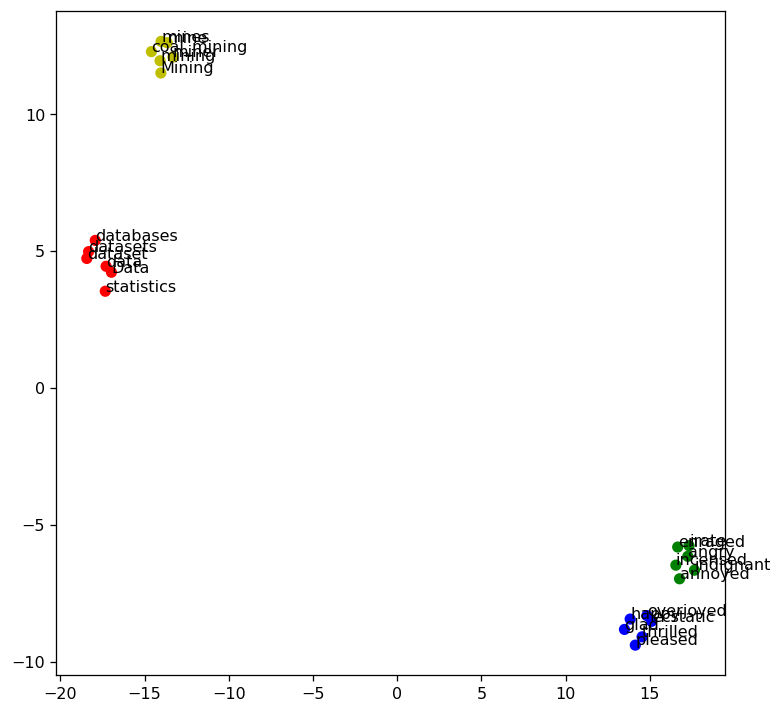

In [86]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## t-SNE model
tsne = TSNE(n_components=2, metric='cosine', random_state=28)

## training
X_tsne = tsne.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_tsne[:target_size, 0], X_tsne[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_tsne[:target_size, 0], X_tsne[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()

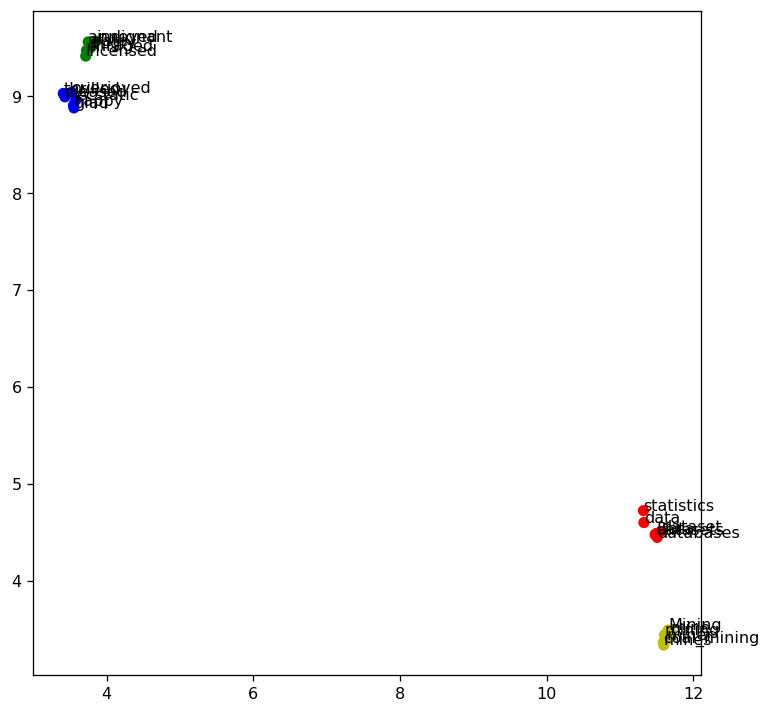

In [89]:
import matplotlib.pyplot as plt
import umap.umap_ as umap

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## UMAP model
umap_model = umap.UMAP(n_components=2, metric='cosine', random_state=28)

## training
X_umap = umap_model.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_umap[:target_size, 0], X_umap[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_umap[:target_size, 0], X_umap[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()


---
##### <a id='toc1_13_2_1_1_'></a>[**>>> Exercise 8 (Take home):**](#toc0_)

Generate a t-SNE and UMAP visualization to show the 15 words most related to the words "angry", "happy", "sad", "fear" (60 words total). Compare the differences between both graphs.

In [90]:
# Answer here
# Exercise 8 - My Answer
# Step 1. Define seed words and parameters
base_emotions = ['angry', 'happy', 'sad', 'fear']
num_related = 15  # top N similar words for each emotion

# Step 2. Retrieve most similar words from pre-trained Word2Vec model
emotion_groups = {}
for emotion in base_emotions:
    similar_terms = [emotion] + [w for w, s in w2v_google_model.most_similar(emotion, topn=num_related)]
    emotion_groups[emotion] = similar_terms

# Step 3. Combine all emotion-related words
target_words_ex8 = sum(emotion_groups.values(), [])  # flatten dictionary values

# Step 4. Assign colors for plotting (use visually distinct palette)
colors_map = {
    'angry': 'red',
    'happy': 'blue',
    'sad': 'green',
    'fear': 'orange'
}
color_ex8 = [colors_map[key] for key in base_emotions for _ in range(num_related + 1)]

# Step 5. Display results
print("Total target words ({}):".format(len(target_words_ex8)))
for emo, words in emotion_groups.items():
    print(f"{emo.capitalize()} → {', '.join(words[:6])} ...")  # show first few examples

print("\nColor assignments:")
print(color_ex8[:10], "...")  # show first few colors


Total target words (64):
Angry → angry, irate, enraged, indignant, incensed, annoyed ...
Happy → happy, glad, pleased, ecstatic, overjoyed, thrilled ...
Sad → sad, saddening, Sad, saddened, heartbreaking, disheartening ...
Fear → fear, fearful, fears, Fear, fearing, worry ...

Color assignments:
['red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red'] ...


In [91]:
# Step 2. Prepare corresponding word vectors for visualization

# Filter out words not existing in the pretrained model
valid_words_ex8 = [w for w in target_words_ex8 if w in w2v_google_model.key_to_index]

# Map each valid word to its corresponding vector
X_ex8 = [w2v_google_model[w] for w in valid_words_ex8]

# Match colors accordingly
color_ex8_valid = [color_ex8[i] for i, w in enumerate(target_words_ex8) if w in w2v_google_model.key_to_index]

# Show results
print(f"Number of valid words: {len(valid_words_ex8)} / {len(target_words_ex8)}")
print(f"Shape of word vectors: {len(X_ex8)} × {len(X_ex8[0])}")


Number of valid words: 64 / 64
Shape of word vectors: 64 × 300


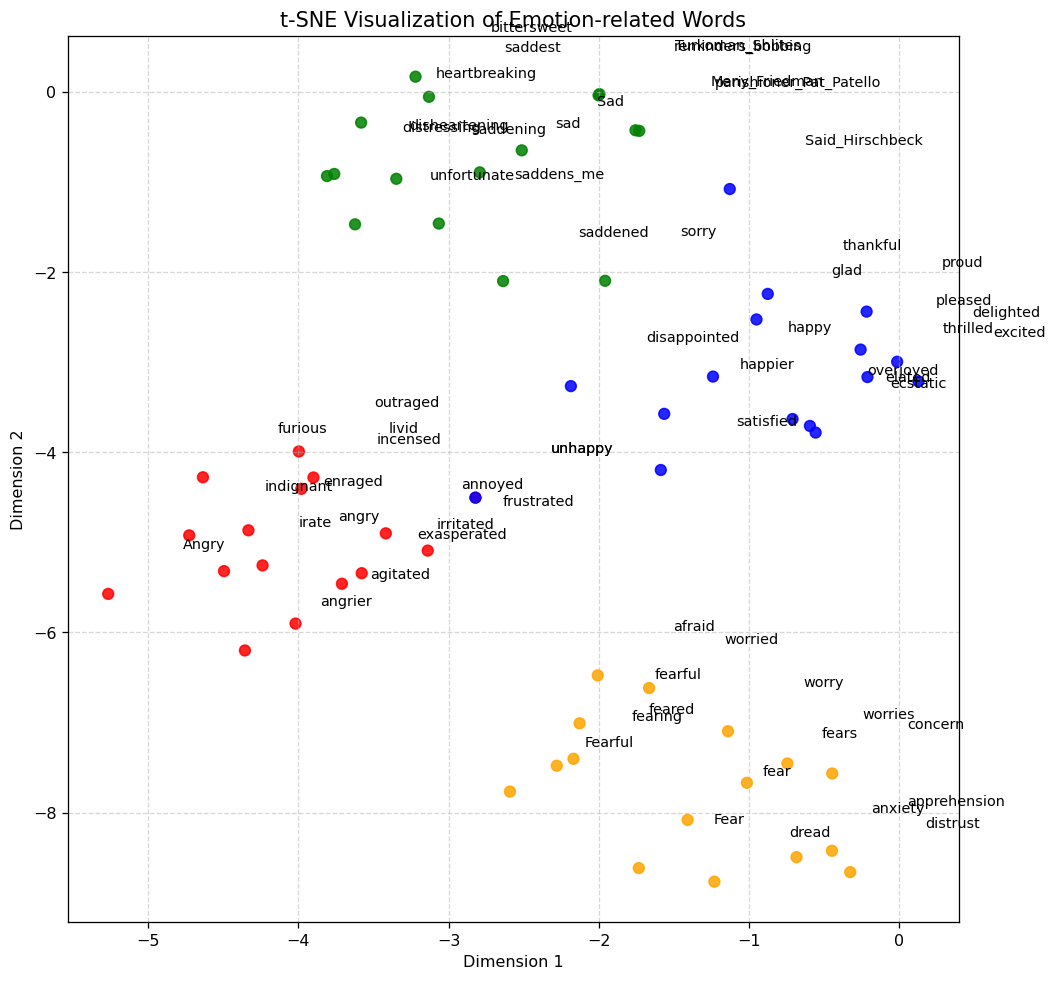

In [96]:
# Step 3. t-SNE dimensionality reduction and visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Initialize and fit t-SNE model (cosine distance)
tsne_model_ex8 = TSNE(
    n_components=2,
    metric='cosine',
    random_state=28,
    init='pca',
    perplexity=30,
    learning_rate='auto'
)

# Convert list of vectors to numpy array and perform embedding
X_tsne_ex8 = tsne_model_ex8.fit_transform(np.array(X_ex8))

# Step 4. Visualization of t-SNE results
plt.figure(figsize=(10, 10), dpi=115)
plt.scatter(X_tsne_ex8[:, 0], X_tsne_ex8[:, 1], c=color_ex8_valid, s=45, alpha=0.85)

# Annotate each word label on the plot
for word, x, y in zip(valid_words_ex8, X_tsne_ex8[:, 0], X_tsne_ex8[:, 1]):
    plt.text(x + 0.5, y + 0.5, word, fontsize=9)

plt.title("t-SNE Visualization of Emotion-related Words", fontsize=13)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


---

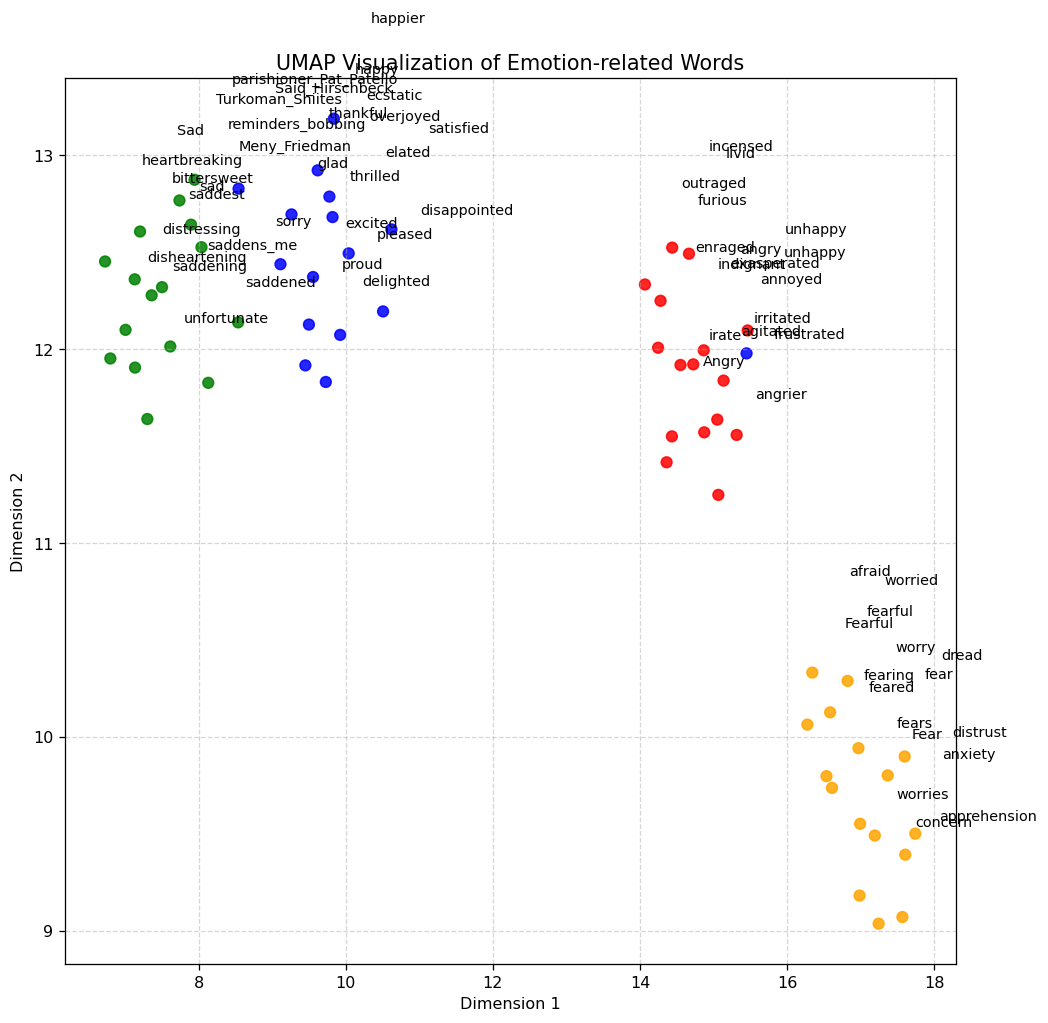

In [98]:
# Step 5. UMAP dimensionality reduction and visualization
import umap.umap_ as umap      # ✅ 強制使用 umap-learn 內的正確子模組
import matplotlib.pyplot as plt
import numpy as np

# Initialize UMAP model
umap_model_ex8 = umap.UMAP(
    n_components=2,
    metric='cosine',
    random_state=28,
    n_neighbors=15,
    min_dist=0.1
)

# Perform dimensionality reduction
X_umap_ex8 = umap_model_ex8.fit_transform(np.array(X_ex8))

# Step 6. Visualization of UMAP results
plt.figure(figsize=(10, 10), dpi=115)
plt.scatter(X_umap_ex8[:, 0], X_umap_ex8[:, 1], c=color_ex8_valid, s=45, alpha=0.85)

# Annotate each word label
for word, x, y in zip(valid_words_ex8, X_umap_ex8[:, 0], X_umap_ex8[:, 1]):
    plt.text(x + 0.5, y + 0.5, word, fontsize=9)

plt.title("UMAP Visualization of Emotion-related Words", fontsize=13)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
